# MailPyme AI: Modelo BETO para clasificación de correos empresariales

## Notebook único para Entregable 1 y Entregable 2

Este notebook cumple dos objetivos:

1. **Entregable 1:** explicar y demostrar el uso de BETO/BERT en español para clasificación automática de texto.
2. **Entregable 2:** evidenciar el modelo entrenado para el MVP MailPyme AI, incluyendo dataset, métricas, matriz de confusión, inferencia, latencia y exportación del modelo.

El modelo ya fue entrenado previamente mediante fine-tuning sobre el dataset del proyecto. Por defecto, este notebook carga el modelo entrenado y ejecuta demostraciones rápidas. El entrenamiento completo se conserva como sección opcional para reproducibilidad.

### Categorías oficiales

- Contratos
- Facturas
- Colaboraciones
- Clientes
- Publicidad
- Varios

> Nota de alcance: este notebook usa datos sintéticos o anonimizados. No se deben cargar correos privados reales, contratos reales, facturas reales ni credenciales.

## 0. Modo de ejecución

Para la presentación, se recomienda mantener:

```python
ENTRENAR_MODELO = False
USAR_MODELO_GUARDADO = True
```

Así el notebook carga el modelo entrenado desde un ZIP y no vuelve a entrenar BETO durante la demo. Porque tentar a Colab en vivo es una tradición académica, pero no una buena decisión técnica.

Si se desea reproducir el fine-tuning completo, cambiar:

```python
ENTRENAR_MODELO = True
```

In [19]:
# =========================
# MODO DE EJECUCIÓN
# =========================

ENTRENAR_MODELO = False          # False para demo rápida; True para repetir fine-tuning
USAR_MODELO_GUARDADO = True      # True para cargar mailpyme_beto_model.zip
EJECUTAR_EMBEDDINGS_CONTEXTUALES = False  # Experimento 2 avanzado. Por defecto se omite para rapidez.
EJECUTAR_INTERFAZ = True         # Muestra interfaz simple de prueba con widgets

print("ENTRENAR_MODELO:", ENTRENAR_MODELO)
print("USAR_MODELO_GUARDADO:", USAR_MODELO_GUARDADO)
print("EJECUTAR_EMBEDDINGS_CONTEXTUALES:", EJECUTAR_EMBEDDINGS_CONTEXTUALES)
print("EJECUTAR_INTERFAZ:", EJECUTAR_INTERFAZ)

ENTRENAR_MODELO: False
USAR_MODELO_GUARDADO: True
EJECUTAR_EMBEDDINGS_CONTEXTUALES: False
EJECUTAR_INTERFAZ: True


## 1. Instalación de librerías

Se usan herramientas gratuitas y compatibles con Google Colab: Hugging Face Transformers, PyTorch, scikit-learn, pandas y matplotlib.

In [2]:
!pip -q install -U transformers datasets accelerate evaluate ipywidgets scikit-learn safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 131.8 MB/s eta 0:00:00


## 2. Imports, semilla y dispositivo

In [4]:
import os
import re
import json
import time
import random
import zipfile
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from IPython.display import display, HTML, Markdown, clear_output

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


## 3. Configuración oficial del proyecto

Esta sección concentra las decisiones que no deben cambiar durante el proyecto: modelo base, categorías, longitud máxima y parámetros principales.

In [5]:
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"

LABELS = [
    "Contratos",
    "Facturas",
    "Colaboraciones",
    "Clientes",
    "Publicidad",
    "Varios",
]

label2id = {label: index for index, label in enumerate(LABELS)}
id2label = {index: label for label, index in label2id.items()}

MAX_LENGTH = 256
EPOCHS = 3
LEARNING_RATE = 2e-5
BATCH_SIZE = 8 if torch.cuda.is_available() else 4

print("Modelo base:", MODEL_NAME)
print("Categorías:", LABELS)
print("label2id:", label2id)
print("MAX_LENGTH:", MAX_LENGTH)
print("BATCH_SIZE:", BATCH_SIZE)

Modelo base: dccuchile/bert-base-spanish-wwm-cased
Categorías: ['Contratos', 'Facturas', 'Colaboraciones', 'Clientes', 'Publicidad', 'Varios']
label2id: {'Contratos': 0, 'Facturas': 1, 'Colaboraciones': 2, 'Clientes': 3, 'Publicidad': 4, 'Varios': 5}
MAX_LENGTH: 256
BATCH_SIZE: 8


# PARTE A: Seminario Entregable 1

Esta parte explica BETO de forma didáctica y muestra experimentos pequeños para la exposición oral.

## 4. ¿Qué es BETO?

BETO es una versión de BERT preentrenada en español. Usa una arquitectura **Transformer** para representar el significado contextual de un texto. A diferencia de un clasificador basado solo en palabras clave, BETO puede considerar la relación entre palabras dentro del asunto, remitente y cuerpo del correo.

En MailPyme AI se adapta BETO con una capa final de clasificación para predecir una de seis categorías oficiales.

Flujo conceptual:

```text
Texto del correo
 -> Tokenizer BETO
 -> input_ids + attention_mask
 -> Encoder Transformer BETO
 -> Representación contextual [CLS]
 -> Capa de clasificación
 -> Softmax sobre 6 categorías
 -> Categoría predicha + confianza
```

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer cargado correctamente.")
print("Tamaño del vocabulario:", tokenizer.vocab_size)
print("Longitud máxima declarada:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Tokenizer cargado correctamente.
Tamaño del vocabulario: 31002
Longitud máxima declarada: 512


## Experimento 1: ¿cómo transforma BETO un correo en tokens?

BETO no recibe palabras directamente. Primero convierte el texto en **tokens** y luego esos tokens en números. Los tokens especiales más importantes son:

- `[CLS]`: resume la secuencia para tareas de clasificación.
- `[SEP]`: marca el final de una secuencia.
- `[PAD]`: rellena secuencias para que tengan igual longitud.
- `[UNK]`: representa tokens desconocidos.

**Decisión:** este experimento se queda porque sirve muy bien para el Entregable 1 y no complica el Entregable 2.

In [7]:
texto_ejemplo = (
    "Asunto: Documento para revisión. "
    "Remitente: legal@empresa-ejemplo.com. "
    "Cuerpo: Adjunto el contrato para su revisión y firma."
)

codificacion = tokenizer(
    texto_ejemplo,
    return_tensors="pt",
    truncation=True,
    max_length=MAX_LENGTH,
)

tokens = tokenizer.convert_ids_to_tokens(codificacion["input_ids"][0])
ids = codificacion["input_ids"][0].tolist()
attention = codificacion["attention_mask"][0].tolist()

tabla_tokens = pd.DataFrame({
    "posicion": list(range(len(tokens))),
    "token": tokens,
    "input_id": ids,
    "attention_mask": attention,
})

display(tabla_tokens.head(40))
print("Cantidad total de tokens:", len(tokens))

,posicion,token,input_id,attention_mask
0,0,[CLS],4,1
1,1,Asunto,12994,1
2,2,:,1181,1
3,3,Documento,17528,1
4,4,para,1110,1
5,5,revisión,6580,1
6,6,.,1009,1
7,7,Rem,13223,1
8,8,##iten,21121,1
9,9,##te,1066,1


Cantidad total de tokens: 31


In [8]:
def mostrar_tokens_coloreados(texto):
    tokens = tokenizer.tokenize(texto)
    html_tokens = " ".join([
        f"""
        <span style="
            display:inline-block;
            background:#eef4ff;
            border:1px solid #b7c9ef;
            border-radius:6px;
            padding:5px 8px;
            margin:3px;
            font-family:monospace;
            color:#1b1b1b;">
            {token}
        </span>
        """
        for token in tokens
    ])

    display(HTML(f"""
        <div style="padding:12px;border:1px solid #ddd;border-radius:8px;">
            <b>Tokens generados por BETO:</b><br><br>
            {html_tokens}
        </div>
    """))

mostrar_tokens_coloreados(texto_ejemplo)

## Experimento 2: una palabra, dos significados

BETO genera representaciones contextuales. Esto significa que una palabra puede tomar significados distintos según la frase.

Compararemos la palabra **firma** en dos contextos:

1. “Adjunto el contrato para que procedan con la firma.”
2. “La firma participará en la feria empresarial de Quito.”

**Decisión:** se conserva como experimento didáctico. La versión profunda con embeddings queda como opcional para no volver pesado el notebook.

In [20]:
frases_contexto = [
    "Adjunto el contrato para que procedan con la firma.",
    "La firma participará en la feria empresarial de Quito.",
]

for frase in frases_contexto:
    print("\nTexto:", frase)
    print("Tokens:", tokenizer.tokenize(frase))



Texto: Adjunto el contrato para que procedan con la firma.
Tokens: ['Adjunto', 'el', 'contrato', 'para', 'que', 'proceda', '##n', 'con', 'la', 'firma', '.']

Texto: La firma participará en la feria empresarial de Quito.
Tokens: ['La', 'firma', 'participar', '##á', 'en', 'la', 'feria', 'empresarial', 'de', 'Quito', '.']


In [21]:
def obtener_embedding_palabra(texto, palabra_objetivo, model, tokenizer):
    texto_lower = texto.lower()
    palabra_lower = palabra_objetivo.lower()
    inicio = texto_lower.find(palabra_lower)
    if inicio == -1:
        raise ValueError(f"No se encontró la palabra '{palabra_objetivo}' en el texto.")
    fin = inicio + len(palabra_objetivo)

    encoding = tokenizer(
        texto,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True,
        max_length=MAX_LENGTH,
    )

    offsets = encoding.pop("offset_mapping")[0].tolist()
    posiciones = [
        idx for idx, (start, end) in enumerate(offsets)
        if start < fin and end > inicio and not (start == 0 and end == 0)
    ]

    if not posiciones:
        raise ValueError("No se encontraron tokens asociados a la palabra objetivo.")

    model_inputs = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**model_inputs)
        hidden_states = outputs.last_hidden_state[0]
        embedding = hidden_states[posiciones].mean(dim=0)

    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])
    return embedding, tokens, posiciones

if EJECUTAR_EMBEDDINGS_CONTEXTUALES:
    context_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
    context_model.eval()

    emb_1, tokens_1, pos_1 = obtener_embedding_palabra(frases_contexto[0], "firma", context_model, tokenizer)
    emb_2, tokens_2, pos_2 = obtener_embedding_palabra(frases_contexto[1], "firma", context_model, tokenizer)

    similitud = torch.nn.functional.cosine_similarity(emb_1, emb_2, dim=0).item()

    print("Tokens frase 1:", tokens_1)
    print("Posiciones de 'firma' frase 1:", pos_1)
    print("Tokens frase 2:", tokens_2)
    print("Posiciones de 'firma' frase 2:", pos_2)
    print("Similitud coseno entre embeddings contextuales:", round(similitud, 4))
else:
    print("Experimento contextual profundo omitido para ejecución rápida.")
    print("Para ejecutarlo, cambia EJECUTAR_EMBEDDINGS_CONTEXTUALES = True al inicio del notebook.")

Experimento contextual profundo omitido para ejecución rápida.
Para ejecutarlo, cambia EJECUTAR_EMBEDDINGS_CONTEXTUALES = True al inicio del notebook.


# PARTE B: Evidencia técnica Entregable 2

Esta parte documenta dataset, preprocesamiento, entrenamiento/evaluación y exportación del modelo.

## 5. Carga del dataset desde GitHub

Se usan las particiones oficiales del repositorio del proyecto:

- `dataset_completo.csv`
- `train.csv`
- `validation.csv`
- `test.csv`

Esto evita dividir los datos de forma distinta cada vez y facilita que el equipo reproduzca los resultados.

In [25]:
BASE_URL = (
    "https://raw.githubusercontent.com/"
    "TheJhonatan144/MAIlPyme/main"
)

URL_COMPLETO = f"{BASE_URL}/data/raw/dataset_completo.csv"
URL_TRAIN = f"{BASE_URL}/data/processed/train.csv"
URL_VAL = f"{BASE_URL}/data/processed/validation.csv"
URL_TEST = f"{BASE_URL}/data/processed/test.csv"

try:
    df_completo = pd.read_csv(URL_COMPLETO)
    train_df = pd.read_csv(URL_TRAIN)
    val_df = pd.read_csv(URL_VAL)
    test_df = pd.read_csv(URL_TEST)

    print("Dataset completo:", df_completo.shape)
    print("Entrenamiento:", train_df.shape)
    print("Validación:", val_df.shape)
    print("Prueba:", test_df.shape)
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar el dataset desde GitHub. "
        "Verifica conexión a internet y que las rutas del repositorio sigan vigentes."
    ) from error

Dataset completo: (680, 7)
Entrenamiento: (544, 7)
Validación: (68, 7)
Prueba: (68, 7)


## 6. Preprocesamiento

La entrada del modelo se construye concatenando:

```text
Asunto: ... Remitente: ... Cuerpo: ...
```

Se aplica una limpieza conservadora: se eliminan saltos excesivos y espacios repetidos, pero se conservan tildes, puntuación y mayúsculas, porque BETO está preparado para procesar español con contexto.

In [26]:
def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto)
    texto = re.sub(r"[\r\n\t]+", " ", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()


def preparar_dataframe(dataframe, nombre):
    df_temp = dataframe.copy()
    columnas_req = ["subject", "sender", "body", "label"]

    faltantes = [col for col in columnas_req if col not in df_temp.columns]
    if faltantes:
        raise ValueError(f"Error en {nombre}: faltan columnas {faltantes}")

    for col in ["subject", "sender", "body", "label"]:
        df_temp[col] = df_temp[col].apply(limpiar_texto)

    etiquetas_invalidas = sorted(set(df_temp["label"].unique()) - set(LABELS))
    if etiquetas_invalidas:
        raise ValueError(f"Error en {nombre}: etiquetas inválidas {etiquetas_invalidas}")

    df_temp["text"] = (
        "Asunto: " + df_temp["subject"] +
        " Remitente: " + df_temp["sender"] +
        " Cuerpo: " + df_temp["body"]
    )

    df_temp["label_id"] = df_temp["label"].map(label2id).astype(int)

    print(f'Dataset "{nombre}" preparado: {df_temp.shape}')
    return df_temp


df_completo = preparar_dataframe(df_completo, "Completo")
train_df = preparar_dataframe(train_df, "Entrenamiento")
val_df = preparar_dataframe(val_df, "Validación")
test_df = preparar_dataframe(test_df, "Prueba")


Dataset "Completo" preparado: (680, 9)
Dataset "Entrenamiento" preparado: (544, 9)
Dataset "Validación" preparado: (68, 9)
Dataset "Prueba" preparado: (68, 9)


## 7. Validación rápida del dataset

Se revisa balance de clases, nulos y posibles cruces exactos entre particiones. Esta sección ayuda a defender que el dataset está controlado y que el test no se mezcla accidentalmente con entrenamiento. Porque sí, el leakage también se disfraza de “buenas métricas”.

Distribución por categoría en dataset completo:


,cantidad
label,
Contratos,110
Facturas,115
Colaboraciones,108
Clientes,123
Publicidad,108
Varios,116



Nulos por columna en train:


,nulos
subject,0
sender,0
body,0
label,0
text,0
label_id,0



Cruces exactos entre particiones:
Train ∩ Val: 0
Train ∩ Test: 1
Val ∩ Test: 0


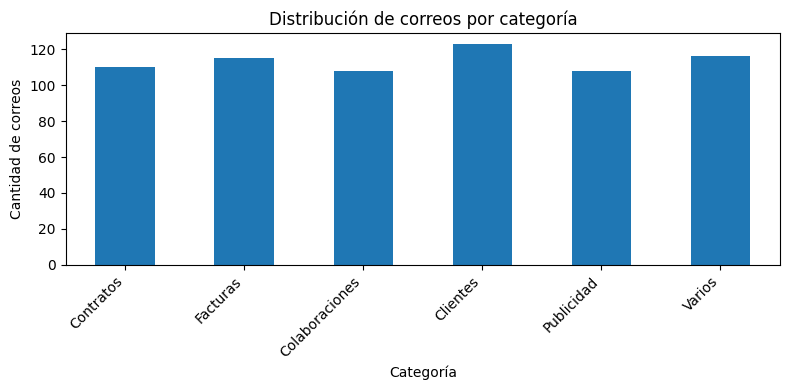

In [27]:
print("Distribución por categoría en dataset completo:")
distribucion = df_completo["label"].value_counts().reindex(LABELS)
display(distribucion.to_frame("cantidad"))

print("\nNulos por columna en train:")
display(train_df[["subject", "sender", "body", "label", "text", "label_id"]].isna().sum().to_frame("nulos"))

train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print("\nCruces exactos entre particiones:")
print("Train ∩ Val:", len(train_texts & val_texts))
print("Train ∩ Test:", len(train_texts & test_texts))
print("Val ∩ Test:", len(val_texts & test_texts))

fig, ax = plt.subplots(figsize=(8, 4))
distribucion.plot(kind="bar", ax=ax)
ax.set_title("Distribución de correos por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de correos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig("distribucion_categorias_mailpyme.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
print("Ejemplos procesados:")
display(df_completo[["subject", "sender", "body", "label", "text", "label_id"]].head(5))

## 8. Cargar o inicializar el modelo

Por defecto, se carga el modelo ya entrenado desde `mailpyme_beto_model.zip`.

Rutas aceptadas:

- `/content/mailpyme_beto_model`
- `/content/content/mailpyme_beto_model`
- un ZIP subido manualmente llamado `mailpyme_beto_model.zip`

Si `ENTRENAR_MODELO = True`, se inicializa BETO desde Hugging Face y se entrena desde las particiones del dataset.

In [29]:
def detectar_carpeta_modelo(base="/content"):
    rutas_directas = [
        "/content/mailpyme_beto_model",
        "/content/content/mailpyme_beto_model",
        "./mailpyme_beto_model",
    ]

    for ruta in rutas_directas:
        if os.path.exists(os.path.join(ruta, "config.json")):
            return ruta

    for root, dirs, files in os.walk(base):
        root_lower = root.lower()
        if "mailpyme" in root_lower and "config.json" in files:
            if "model.safetensors" in files or "pytorch_model.bin" in files:
                return root
    return None


def extraer_zip_modelo(zip_path="/content/mailpyme_beto_model.zip"):
    if not os.path.exists(zip_path):
        return None

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("/content/")

    return detectar_carpeta_modelo("/content")


def cargar_modelo_guardado():
    model_dir = detectar_carpeta_modelo("/content")

    if model_dir is None:
        model_dir = extraer_zip_modelo("/content/mailpyme_beto_model.zip")

    if model_dir is None:
        try:
            from google.colab import files
            print("Sube el archivo mailpyme_beto_model.zip")
            uploaded = files.upload()

            for nombre_archivo in uploaded.keys():
                if nombre_archivo.endswith(".zip"):
                    zip_path = f"/content/{nombre_archivo}"
                    model_dir = extraer_zip_modelo(zip_path)
                    break
        except Exception as error:
            raise RuntimeError("No se pudo abrir el selector de archivos de Colab.") from error

    if model_dir is None:
        raise FileNotFoundError(
            "No se encontró una carpeta válida del modelo. "
            "Sube mailpyme_beto_model.zip o cambia ENTRENAR_MODELO = True."
        )

    print("Carpeta del modelo detectada:", model_dir)
    loaded_tokenizer = AutoTokenizer.from_pretrained(model_dir)
    loaded_model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    loaded_model.to(device)
    loaded_model.eval()

    return loaded_model, loaded_tokenizer, model_dir


if ENTRENAR_MODELO:
    print("Modo entrenamiento activado. Se inicializa BETO desde Hugging Face.")
    classification_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABELS),
        id2label=id2label,
        label2id=label2id,
    )
    classification_model.to(device)
    MODEL_DIR = None
else:
    print("Modo demo/evidencia activado. Se carga el modelo ya entrenado.")
    classification_model, tokenizer, MODEL_DIR = cargar_modelo_guardado()

print("Modelo listo para usar.")

Modo demo/evidencia activado. Se carga el modelo ya entrenado.
Sube el archivo mailpyme_beto_model.zip


Saving mailpyme_beto_model.zip to mailpyme_beto_model.zip
Carpeta del modelo detectada: /content/content/mailpyme_beto_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Modelo listo para usar.


## 9. Dataset de PyTorch y DataLoaders

In [30]:
class EmailDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=MAX_LENGTH):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label_id"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


train_dataset = EmailDataset(train_df, tokenizer)
val_dataset = EmailDataset(val_df, tokenizer)
test_dataset = EmailDataset(test_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders listos.")
print("Batches train:", len(train_loader))
print("Batches validation:", len(val_loader))
print("Batches test:", len(test_loader))

DataLoaders listos.
Batches train: 68
Batches validation: 9
Batches test: 9


## 10. Funciones de entrenamiento y evaluación

La evaluación se usa siempre. El entrenamiento solo se ejecuta si `ENTRENAR_MODELO = True`.

In [31]:
def calcular_metricas(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def entrenar_una_epoca(model, data_loader, optimizer, scheduler):
    model.train()
    losses = []
    predictions = []
    true_labels = []

    for batch in data_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels_batch,
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        preds = torch.argmax(logits, dim=1)

        losses.append(loss.item())
        predictions.extend(preds.detach().cpu().numpy())
        true_labels.extend(labels_batch.detach().cpu().numpy())

    metricas = calcular_metricas(true_labels, predictions)
    metricas["loss"] = float(np.mean(losses))
    return metricas


def evaluar_modelo(model, data_loader):
    model.eval()
    losses = []
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels_batch,
            )

            loss = outputs.loss
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            losses.append(loss.item())
            predictions.extend(preds.detach().cpu().numpy())
            true_labels.extend(labels_batch.detach().cpu().numpy())

    metricas = calcular_metricas(true_labels, predictions)
    metricas["loss"] = float(np.mean(losses))
    metricas["true_labels"] = true_labels
    metricas["predictions"] = predictions
    return metricas

## 11. Entrenamiento opcional del modelo

Esta sección se conserva por reproducibilidad. En la presentación oral no se recomienda entrenar en vivo. El camino sensato, esa especie en peligro de extinción, es cargar el modelo ya entrenado.

In [32]:
historial = []

if ENTRENAR_MODELO:
    optimizer = AdamW(classification_model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps,
    )

    inicio_entrenamiento = time.perf_counter()

    for epoch in range(EPOCHS):
        train_metrics = entrenar_una_epoca(classification_model, train_loader, optimizer, scheduler)
        val_metrics = evaluar_modelo(classification_model, val_loader)

        registro = {
            "epoca": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
        }
        historial.append(registro)

        print(
            f"Época {epoch + 1}/{EPOCHS} | "
            f"Train loss: {train_metrics['loss']:.4f} | "
            f"Train accuracy: {train_metrics['accuracy']:.4f} | "
            f"Val loss: {val_metrics['loss']:.4f} | "
            f"Val accuracy: {val_metrics['accuracy']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

    duracion_entrenamiento = time.perf_counter() - inicio_entrenamiento
    print(f"\nEntrenamiento finalizado en {duracion_entrenamiento / 60:.2f} minutos.")
else:
    print("Entrenamiento omitido. Se usará el modelo cargado previamente.")


Entrenamiento omitido. Se usará el modelo cargado previamente.


In [33]:
if historial:
    historial_df = pd.DataFrame(historial)
    display(historial_df)
    historial_df.to_csv("historial_entrenamiento_beto_mailpyme.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(historial_df["epoca"], historial_df["train_loss"], marker="o", label="Train loss")
    ax.plot(historial_df["epoca"], historial_df["val_loss"], marker="o", label="Val loss")
    ax.set_title("Evolución de la pérdida")
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    fig.savefig("loss_beto_mailpyme.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(historial_df["epoca"], historial_df["train_accuracy"], marker="o", label="Train accuracy")
    ax.plot(historial_df["epoca"], historial_df["val_accuracy"], marker="o", label="Val accuracy")
    ax.set_title("Evolución de accuracy")
    ax.set_xlabel("Época")
    ax.set_ylabel("Accuracy")
    ax.legend()
    plt.tight_layout()
    fig.savefig("accuracy_beto_mailpyme.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No hay historial nuevo porque el entrenamiento fue omitido.")

No hay historial nuevo porque el entrenamiento fue omitido.


## 12. Evaluación final en test

La evaluación en test usa datos no vistos por el modelo durante el entrenamiento. Es la evidencia principal para el Entregable 2.

In [34]:
test_metrics = evaluar_modelo(classification_model, test_loader)

metricas_finales = pd.DataFrame([{
    "accuracy": test_metrics["accuracy"],
    "precision_weighted": test_metrics["precision"],
    "recall_weighted": test_metrics["recall"],
    "f1_weighted": test_metrics["f1"],
    "test_loss": test_metrics["loss"],
}])

print("Métricas finales en test:")
display(metricas_finales)
metricas_finales.to_csv("metricas_beto_mailpyme.csv", index=False)

Métricas finales en test:


,accuracy,precision_weighted,recall_weighted,f1_weighted,test_loss
0,0.985294,0.98652,0.985294,0.985294,0.059005


In [35]:
reporte = classification_report(
    test_metrics["true_labels"],
    test_metrics["predictions"],
    labels=list(range(len(LABELS))),
    target_names=LABELS,
    zero_division=0,
    output_dict=True,
)

reporte_df = pd.DataFrame(reporte).transpose()
display(reporte_df)
reporte_df.to_csv("classification_report_beto_mailpyme.csv")

,precision,recall,f1-score,support
Contratos,1.000000,1.000000,1.000000,11.000000
Facturas,1.000000,0.916667,0.956522,12.000000
Colaboraciones,1.000000,1.000000,1.000000,11.000000
Clientes,1.000000,1.000000,1.000000,12.000000
Publicidad,1.000000,1.000000,1.000000,11.000000
Varios,0.916667,1.000000,0.956522,11.000000
accuracy,0.985294,0.985294,0.985294,0.985294
macro avg,0.986111,0.986111,0.985507,68.000000
weighted avg,0.986520,0.985294,0.985294,68.000000


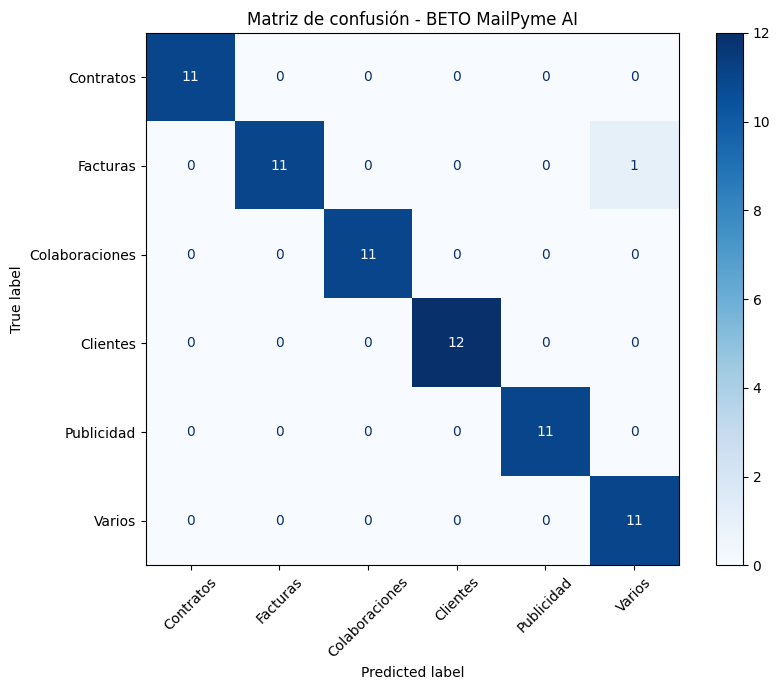

In [36]:
cm = confusion_matrix(
    test_metrics["true_labels"],
    test_metrics["predictions"],
    labels=list(range(len(LABELS))),
)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=45, colorbar=True)
ax.set_title("Matriz de confusión - BETO MailPyme AI")
plt.tight_layout()
fig.savefig("matriz_confusion_beto_mailpyme.png", dpi=300, bbox_inches="tight")
plt.show()

# PARTE C: Demo de clasificación e inferencia

Esta parte sirve tanto para Entregable 1 como para Entregable 2. Muestra cómo el modelo clasifica correos nuevos y entrega categoría, confianza y estado.

## 13. Función de clasificación individual

In [37]:
def estado_por_confianza(confianza):
    if confianza >= 0.70:
        return "Clasificado"
    if confianza >= 0.50:
        return "Baja confianza"
    return "Revisión sugerida"


def clasificar_correo(subject, sender, body, devolver_probabilidades=False):
    texto = f"Asunto: {limpiar_texto(subject)} Remitente: {limpiar_texto(sender)} Cuerpo: {limpiar_texto(body)}"

    inputs = tokenizer(
        texto,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}

    classification_model.eval()
    with torch.no_grad():
        outputs = classification_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)[0]

    predicted_id = int(torch.argmax(probs).item())
    confianza = float(probs[predicted_id].item())
    categoria = id2label[predicted_id]

    resultado = {
        "categoria": categoria,
        "confianza": round(confianza, 4),
        "estado": estado_por_confianza(confianza),
        "texto_modelo": texto,
    }

    if devolver_probabilidades:
        resultado["probabilidades"] = {
            id2label[i]: round(float(probs[i].item()), 4)
            for i in range(len(LABELS))
        }

    return resultado

In [38]:
resultado_demo = clasificar_correo(
    subject="Revisión de contrato para firma",
    sender="gerencia@empresa-demo.com",
    body="Adjunto el contrato actualizado para revisar las cláusulas antes de la firma.",
    devolver_probabilidades=True,
)

resultado_demo

{'categoria': 'Contratos',
 'confianza': 0.9956,
 'estado': 'Clasificado',
 'texto_modelo': 'Asunto: Revisión de contrato para firma Remitente: gerencia@empresa-demo.com Cuerpo: Adjunto el contrato actualizado para revisar las cláusulas antes de la firma.',
 'probabilidades': {'Contratos': 0.9956,
  'Facturas': 0.0008,
  'Colaboraciones': 0.0011,
  'Clientes': 0.0009,
  'Publicidad': 0.0009,
  'Varios': 0.0008}}

In [39]:
def mostrar_resultado(resultado):
    probs = resultado.get("probabilidades", {})
    tabla_probs = ""
    if probs:
        filas = "".join([
            f"<tr><td>{categoria}</td><td>{probabilidad:.4f}</td></tr>"
            for categoria, probabilidad in probs.items()
        ])
        tabla_probs = f"""
        <br><b>Probabilidades por categoría:</b>
        <table style="border-collapse:collapse;margin-top:8px;">
            <tr><th style="border:1px solid #ccc;padding:4px;">Categoría</th><th style="border:1px solid #ccc;padding:4px;">Probabilidad</th></tr>
            {filas}
        </table>
        """

    display(HTML(f"""
    <div style="border:1px solid #ccc;border-radius:10px;padding:14px;max-width:760px;">
        <h3>Resultado de clasificación</h3>
        <p><b>Categoría:</b> {resultado['categoria']}</p>
        <p><b>Confianza:</b> {resultado['confianza']}</p>
        <p><b>Estado:</b> {resultado['estado']}</p>
        {tabla_probs}
    </div>
    """))

mostrar_resultado(resultado_demo)

Categoría,Probabilidad
Contratos,0.9956
Facturas,0.0008
Colaboraciones,0.0011
Clientes,0.0009
Publicidad,0.0009
Varios,0.0008


## Experimento 3: contexto progresivo

Este experimento muestra cómo cambia la predicción cuando el modelo recibe solo asunto, luego asunto + remitente y finalmente el correo completo.

**Decisión:** se conserva porque demuestra por qué la entrada oficial del modelo usa asunto + remitente + cuerpo. Sirve para Entregable 1 y también justifica decisiones del MVP en Entregable 2.

In [40]:
correo_contexto = {
    "subject": "Documento pendiente para revisión",
    "sender": "legal@empresa-demo.com",
    "body": "Buenas tardes, adjunto el contrato actualizado para revisar cláusulas, fechas y condiciones antes de proceder con la firma.",
}

variantes_contexto = [
    {
        "caso": "Solo asunto",
        "subject": correo_contexto["subject"],
        "sender": "",
        "body": "",
    },
    {
        "caso": "Asunto + remitente",
        "subject": correo_contexto["subject"],
        "sender": correo_contexto["sender"],
        "body": "",
    },
    {
        "caso": "Asunto + remitente + cuerpo",
        "subject": correo_contexto["subject"],
        "sender": correo_contexto["sender"],
        "body": correo_contexto["body"],
    },
]

resultados_contexto = []
for variante in variantes_contexto:
    res = clasificar_correo(
        variante["subject"],
        variante["sender"],
        variante["body"],
        devolver_probabilidades=False,
    )
    resultados_contexto.append({
        "caso": variante["caso"],
        "categoria": res["categoria"],
        "confianza": res["confianza"],
        "estado": res["estado"],
    })

df_contexto = pd.DataFrame(resultados_contexto)
display(df_contexto)

,caso,categoria,confianza,estado
0,Solo asunto,Contratos,0.9766,Clasificado
1,Asunto + remitente,Contratos,0.9910,Clasificado
2,Asunto + remitente + cuerpo,Contratos,0.9953,Clasificado


## Experimento 4: modificar una frase

Este experimento compara correos parecidos con intenciones distintas. Es útil para explicar que el modelo no debería depender solo de palabras sueltas, sino de la intención global del mensaje.

**Decisión:** se conserva, pero reducido a pocos casos claros para no hacer el notebook eterno. Ya bastante hace la humanidad con sus reuniones.

In [41]:
casos_modificados = [
    {
        "caso": "Contrato como intención principal",
        "subject": "Revisión de documento pendiente",
        "sender": "legal@empresa-demo.com",
        "body": "Adjunto la factura como referencia, pero el motivo principal es revisar el contrato y confirmar las cláusulas antes de la firma.",
        "esperado": "Contratos",
    },
    {
        "caso": "Factura como intención principal",
        "subject": "Documento del servicio de junio",
        "sender": "contabilidad@proveedor-demo.com",
        "body": "Adjunto el contrato firmado anteriormente y la factura correspondiente al servicio de junio para gestionar el pago pendiente.",
        "esperado": "Facturas",
    },
    {
        "caso": "Cliente solicita cotización",
        "subject": "Consulta sobre planes disponibles",
        "sender": "compras@cliente-demo.com",
        "body": "Necesitamos información sobre precios, tiempos de atención y condiciones del servicio para nuestra oficina en Quito.",
        "esperado": "Clientes",
    },
    {
        "caso": "Publicidad masiva",
        "subject": "Promoción especial por tiempo limitado",
        "sender": "newsletter@promo-demo.com",
        "body": "Aprovecha descuento especial en software empresarial. Oferta válida solo esta semana para nuevos usuarios.",
        "esperado": "Publicidad",
    },
]

filas = []
for caso in casos_modificados:
    res = clasificar_correo(caso["subject"], caso["sender"], caso["body"])
    filas.append({
        "caso": caso["caso"],
        "esperado": caso["esperado"],
        "predicho": res["categoria"],
        "confianza": res["confianza"],
        "estado": res["estado"],
    })

df_modificaciones = pd.DataFrame(filas)
display(df_modificaciones)

,caso,esperado,predicho,confianza,estado
0,Contrato como intención principal,Contratos,Contratos,0.9959,Clasificado
1,Factura como intención principal,Facturas,Facturas,0.9958,Clasificado
2,Cliente solicita cotización,Clientes,Clientes,0.9903,Clasificado
3,Publicidad masiva,Publicidad,Publicidad,0.9963,Clasificado


## 14. Interfaz interactiva opcional

Esta interfaz permite probar correos nuevos desde el mismo notebook. Para la demo, es más seguro ejecutar esta celda después de cargar el modelo entrenado.

In [42]:
if EJECUTAR_INTERFAZ:
    try:
        import ipywidgets as widgets

        subject_widget = widgets.Text(
            value="Solicitud de cotización para servicio mensual",
            description="Asunto:",
            layout=widgets.Layout(width="90%"),
        )
        sender_widget = widgets.Text(
            value="compras@empresa-demo.com",
            description="Remitente:",
            layout=widgets.Layout(width="90%"),
        )
        body_widget = widgets.Textarea(
            value="Buenas tardes, quisiera conocer el precio del servicio de soporte para nuestra oficina en Quito. Por favor enviar detalles de planes y tiempos de atención.",
            description="Cuerpo:",
            layout=widgets.Layout(width="90%", height="140px"),
        )
        boton = widgets.Button(description="Clasificar correo", button_style="primary")
        salida = widgets.Output()

        ejemplos = {
            "Clientes": {
                "subject": "Solicitud de información sobre precios",
                "sender": "contacto@cliente-demo.com",
                "body": "Buenas tardes, necesitamos información sobre planes, costos y tiempos de atención para contratar el servicio.",
            },
            "Facturas": {
                "subject": "Factura correspondiente al servicio de junio",
                "sender": "contabilidad@proveedor-demo.com",
                "body": "Adjuntamos la factura del servicio prestado durante junio para que puedan gestionar el pago pendiente.",
            },
            "Contratos": {
                "subject": "Contrato para revisión y firma",
                "sender": "legal@empresa-demo.com",
                "body": "Adjunto el contrato actualizado para revisar cláusulas, anexos y condiciones antes de la firma.",
            },
            "Colaboraciones": {
                "subject": "Propuesta de alianza comercial",
                "sender": "alianzas@marca-demo.com",
                "body": "Nos gustaría proponer una colaboración entre nuestras empresas para una campaña conjunta durante el próximo mes.",
            },
            "Publicidad": {
                "subject": "Promoción especial para empresas",
                "sender": "newsletter@promo-demo.com",
                "body": "Aprovecha descuento por tiempo limitado en herramientas digitales para negocios.",
            },
            "Varios": {
                "subject": "Invitación a charla informativa",
                "sender": "eventos@institucion-demo.com",
                "body": "Les invitamos a una charla gratuita sobre transformación digital el próximo viernes.",
            },
        }

        selector = widgets.Dropdown(options=list(ejemplos.keys()), description="Ejemplo:")
        cargar_ejemplo = widgets.Button(description="Cargar ejemplo")

        def on_cargar_ejemplo(_):
            ejemplo = ejemplos[selector.value]
            subject_widget.value = ejemplo["subject"]
            sender_widget.value = ejemplo["sender"]
            body_widget.value = ejemplo["body"]

        def on_clasificar(_):
            with salida:
                clear_output()
                resultado = clasificar_correo(
                    subject_widget.value,
                    sender_widget.value,
                    body_widget.value,
                    devolver_probabilidades=True,
                )
                mostrar_resultado(resultado)

        cargar_ejemplo.on_click(on_cargar_ejemplo)
        boton.on_click(on_clasificar)

        display(widgets.VBox([
            widgets.HBox([selector, cargar_ejemplo]),
            subject_widget,
            sender_widget,
            body_widget,
            boton,
            salida,
        ]))

    except Exception as error:
        print("No se pudo cargar la interfaz interactiva:", error)
else:
    print("Interfaz omitida. Cambia EJECUTAR_INTERFAZ = True para mostrarla.")

# PARTE D: Métricas técnicas y exportación

## 15. Latencia de inferencia

Esta métrica mide el tiempo que tarda el modelo en clasificar un correo. Sirve como evidencia técnica para el Entregable 2, aunque la prueba completa de concurrencia le corresponde a la aplicación integrada.

Resumen de latencia de inferencia:


,valor_ms
mean,13.292331
median,11.798522
min,11.309456
max,26.143861
std,3.781342


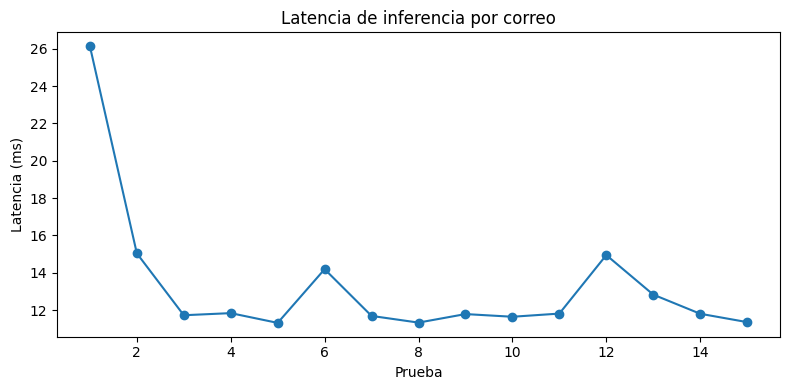

In [43]:
correos_latencia = [
    {
        "subject": "Factura pendiente de pago",
        "sender": "contabilidad@proveedor-demo.com",
        "body": "Adjuntamos la factura correspondiente al servicio prestado para gestionar el pago pendiente.",
    },
    {
        "subject": "Contrato actualizado",
        "sender": "legal@empresa-demo.com",
        "body": "Enviamos el contrato actualizado para revisión de cláusulas y firma.",
    },
    {
        "subject": "Consulta sobre servicio",
        "sender": "cliente@empresa-demo.com",
        "body": "Quisiera conocer precios y disponibilidad del servicio para nuestra oficina.",
    },
] * 5

tiempos_ms = []
for correo in correos_latencia:
    inicio = time.perf_counter()
    _ = clasificar_correo(correo["subject"], correo["sender"], correo["body"])
    fin = time.perf_counter()
    tiempos_ms.append((fin - inicio) * 1000)

latencia_df = pd.DataFrame({"latencia_ms": tiempos_ms})
latencia_resumen = latencia_df["latencia_ms"].agg(["mean", "median", "min", "max", "std"]).to_frame("valor_ms")

print("Resumen de latencia de inferencia:")
display(latencia_resumen)
latencia_resumen.to_csv("latencia_beto_mailpyme.csv")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(tiempos_ms) + 1), tiempos_ms, marker="o")
ax.set_title("Latencia de inferencia por correo")
ax.set_xlabel("Prueba")
ax.set_ylabel("Latencia (ms)")
plt.tight_layout()
fig.savefig("latencia_beto_mailpyme.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Guardar y comprimir modelo

Esta sección exporta el modelo en formato compatible con Hugging Face para que el backend pueda cargarlo con:

```python
AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
AutoTokenizer.from_pretrained(MODEL_DIR)
```

In [44]:
OUTPUT_DIR = "/content/mailpyme_beto_model"
ZIP_PATH = "/content/mailpyme_beto_model.zip"

classification_model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

configuracion_mailpyme = {
    "model_name": MODEL_NAME,
    "labels": LABELS,
    "label2id": label2id,
    "id2label": id2label,
    "max_length": MAX_LENGTH,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "entrenamiento_ejecutado_en_esta_corrida": ENTRENAR_MODELO,
}

with open(os.path.join(OUTPUT_DIR, "mailpyme_config.json"), "w", encoding="utf-8") as file:
    json.dump(configuracion_mailpyme, file, ensure_ascii=False, indent=2)

special_tokens_path = os.path.join(OUTPUT_DIR, "special_tokens_map.json")
if not os.path.exists(special_tokens_path):
    special_tokens = {
        "unk_token": "[UNK]",
        "sep_token": "[SEP]",
        "pad_token": "[PAD]",
        "cls_token": "[CLS]",
        "mask_token": "[MASK]",
    }
    with open(special_tokens_path, "w", encoding="utf-8") as file:
        json.dump(special_tokens, file, ensure_ascii=False, indent=2)

print("Archivos exportados:")
print(os.listdir(OUTPUT_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Archivos exportados:
['config.json', 'mailpyme_config.json', 'tokenizer.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer_config.json']


In [ ]:
modelo_recargado = AutoModelForSequenceClassification.from_pretrained(OUTPUT_DIR)
tokenizer_recargado = AutoTokenizer.from_pretrained(OUTPUT_DIR)

modelo_recargado.to(device)
modelo_recargado.eval()

print("Modelo recargado correctamente desde la carpeta exportada.")

In [ ]:
!zip -r /content/mailpyme_beto_model.zip /content/mailpyme_beto_model > /dev/null
print("ZIP creado:", ZIP_PATH)

## 17. Descargar evidencias

Ejecuta esta celda al final para descargar el modelo y los archivos de evidencia.

In [46]:
archivos_evidencia = [
    "/content/mailpyme_beto_model.zip",
    "metricas_beto_mailpyme.csv",
    "classification_report_beto_mailpyme.csv",
    "matriz_confusion_beto_mailpyme.png",
    "distribucion_categorias_mailpyme.png",
    "latencia_beto_mailpyme.csv",
    "latencia_beto_mailpyme.png",
]

if os.path.exists("historial_entrenamiento_beto_mailpyme.csv"):
    archivos_evidencia.append("historial_entrenamiento_beto_mailpyme.csv")
if os.path.exists("loss_beto_mailpyme.png"):
    archivos_evidencia.append("loss_beto_mailpyme.png")
if os.path.exists("accuracy_beto_mailpyme.png"):
    archivos_evidencia.append("accuracy_beto_mailpyme.png")

for archivo in archivos_evidencia:
    print(archivo, "✅" if os.path.exists(archivo) else "❌")

try:
    from google.colab import files
    for archivo in archivos_evidencia:
        if os.path.exists(archivo):
            files.download(archivo)
except Exception:
    print("Descarga automática disponible solo en Google Colab. Los archivos ya quedaron generados en el entorno.")

/content/mailpyme_beto_model.zip ✅
metricas_beto_mailpyme.csv ✅
classification_report_beto_mailpyme.csv ✅
matriz_confusion_beto_mailpyme.png ✅
distribucion_categorias_mailpyme.png ✅
latencia_beto_mailpyme.csv ✅
latencia_beto_mailpyme.png ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# PARTE E: Resumen final para la defensa

In [45]:
resumen_md = f"""
## Resumen final del modelo

El modelo utilizado fue **BETO** (`{MODEL_NAME}`), adaptado mediante fine-tuning para clasificación multiclase de correos empresariales.

### Entrada del modelo

La entrada se construye concatenando:

- Asunto
- Remitente
- Cuerpo del correo

Formato usado:

```text
Asunto: ... Remitente: ... Cuerpo: ...
```

### Categorías oficiales

{chr(10).join([f"- {label}" for label in LABELS])}

### Dataset usado

Se usaron las particiones disponibles en GitHub:

- Entrenamiento: {len(train_df)} correos
- Validación: {len(val_df)} correos
- Prueba: {len(test_df)} correos

### Resultados en test

- Accuracy: {test_metrics['accuracy']:.4f}
- Precision ponderada: {test_metrics['precision']:.4f}
- Recall ponderado: {test_metrics['recall']:.4f}
- F1 ponderado: {test_metrics['f1']:.4f}

### Limitación principal

El dataset es sintético y balanceado, por lo que las métricas son útiles para validar el flujo técnico del MVP, pero no representan todavía desempeño garantizado en correos reales de MiPYMEs. En una versión futura se recomienda validar con correos anonimizados y ampliar la diversidad del dataset.

### Uso posterior

El modelo exportado puede ser usado por el backend con `AutoModelForSequenceClassification.from_pretrained()` y `AutoTokenizer.from_pretrained()`.
"""

display(Markdown(resumen_md))


## Resumen final del modelo

El modelo utilizado fue **BETO** (`dccuchile/bert-base-spanish-wwm-cased`), adaptado mediante fine-tuning para clasificación multiclase de correos empresariales.

### Entrada del modelo

La entrada se construye concatenando:

- Asunto
- Remitente
- Cuerpo del correo

Formato usado:

```text
Asunto: ... Remitente: ... Cuerpo: ...
```

### Categorías oficiales

- Contratos
- Facturas
- Colaboraciones
- Clientes
- Publicidad
- Varios

### Dataset usado

Se usaron las particiones disponibles en GitHub:

- Entrenamiento: 544 correos
- Validación: 68 correos
- Prueba: 68 correos

### Resultados en test

- Accuracy: 0.9853
- Precision ponderada: 0.9865
- Recall ponderado: 0.9853
- F1 ponderado: 0.9853

### Limitación principal

El dataset es sintético y balanceado, por lo que las métricas son útiles para validar el flujo técnico del MVP, pero no representan todavía desempeño garantizado en correos reales de MiPYMEs. En una versión futura se recomienda validar con correos anonimizados y ampliar la diversidad del dataset.

### Uso posterior

El modelo exportado puede ser usado por el backend con `AutoModelForSequenceClassification.from_pretrained()` y `AutoTokenizer.from_pretrained()`.
